# **Model-based Collaborative Filtering (Matrix Factorization)**

#### Why earlier methods are not good ?
- These are memory-based methods
    - Popularity model
    - Content-based filtering
    - Item-item collaborative filtering<br>
- Problems:
    - Sparse matrix (too many ?)
    - Cold start issues
    - Hard to scale to millions of users

- Instead of comparing books directly like KNN, SVD learns hidden features
- It discovers patterns like :
    - users who love fantasy
    - users who love romance
    - books with deep story
    - books for beginners <br>
   These are called latent factors
- So instead of similarity, we predict ratings<br><br>

### **SVD**

- SVD says :
    - Users don’t rate items randomly
    - Ratings depend on hidden factors
      
- Example hidden factors for movies/books :


| Hidden Feature | Meaning              |
|----------------|----------------------|
| F1             | Action vs Romance    |
| F2             | Funny vs Serious     |
| F3             | New vs Old           |
| F4             | Popularity           |

#### Matrix Factorization Idea

- We start with big rating matrix R
- Users × Items
- SVD breaks it into two smaller matrices

**𝑅 ≈ 𝑃 × 𝑄^T**

- P = User feature matrix
- Q = Item feature matrix

**User matrix (P)**
| User | F1  | F2  | F3  |
|------|-----|-----|-----|
| U1   | 0.9 | 0.1 | 0.8 |
| U2   | 0.7 | 0.3 | 0.6 |

- Interpretation:
    - U1 loves action (0.9)
    - U1 likes new movies (0.8)

**Item matrix (Q)**
| Item   | F1  | F2  | F3  |
|--------|-----|-----|-----|
| Book A | 0.8 | 0.2 | 0.7 |
| Book B | 0.2 | 0.9 | 0.4 |

- Interpretation:
    - Book A = action book
    - Book B = romantic book

**The real problem SVD solves in dataset**

- dataset is extremely sparse

| User | Book A | Book B | Book C | Book D |
|------|--------|--------|--------|--------|
| U1   | 5      | ?      | 3      | ?      |
| U2   | 4      | 2      | ?      | ?      |
| U3   | ?      | 5      | 4      | ?      |
| U4   | 1      | ?      | ?      | 5      |

- Matrix is 99.8% empty
- Goal : Predict the missing ratings
- Example:
    - What rating will U1 give Book B?

- Similarity methods fail because:
    - Users rarely rate same books
    - Hard to find neighbours
      
- Think of SVD as compression
    - Users × Books = 50k × 10k = 500 million cells
    - User matrix  = 50k × 50
    - Book matrix  = 10k × 50

- Dataset doesn't contain :
    - genre
    - writing style
    - complexity
    - audience age
    - romance level
    - fantasy level <br>
    But SVD discovers them automatically from ratings<br><br>

- It learns:
    - user preference for each factor
    - book strength for each factor
Without any metadata

#### How prediction happens

To predict rating : r̂_ui = P_u · Q_i

- User U1 vector: (0.9, 0.1, 0.8)

- Book B vector: (0.2, 0.9, 0.4)

- Multiply and sum:

0.9×0.2+0.1×0.9+0.8×0.4<br>
= 0.18+0.09+0.32<br>
=0.59

- Scaled to rating → predicted rating

#### How model learns these matrices

This is the training part

We start with **random values** in matrices **P** and **Q**

Then we minimize the prediction error

**Error for one rating**
Error = (Real Rating - Predicted Rating)^2

**Loss Function**
∑ ( r_ui - p_u . q_i )^2 + regularization

**Optimization**
We update parameters using **Gradient Descent**
Repeat the process **thousands of times** until the error becomes very small

#### Add Bias
- Real rating depends on more than taste
    - Some users always rate high ⭐⭐⭐⭐⭐
    - Some movies always get high ratings
      
So final formula : **r_ui = μ + b_u + bi + P_u . Q_i**
| Term      | Meaning                  |
|-----------|--------------------------|
| μ         | Global average rating    |
| b_u       | User bias                |
| b_i       | Item bias                |
| P_u · Q_i | Interaction (taste match)|

## scikit-surprise installation

!python --version

import struct<br>
print(struct.calcsize("P") * 8, "bit")

conda create -n recsys310 python=3.10 # Since we are on Python 3.13, pre-built wheels might not exist yet let downgrade python<br>
conda activate recsys310<br>
conda install -c conda-forge jupyter numpy scipy cython pandas matplotlib scikit-learn<br>
pip install scikit-surprise<br>

// --name → internal environment name<br>
// --display-name → how it shows up in Jupyter Notebook’s kernel list<br>
conda install ipykernel<br>
python -m ipykernel install --user --name recsys310 --display-name "Recsys Python 3.10"<br>

// Open your notebook → go to Kernel → Change kernel → Recsys Python 3.10<br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader
from surprise import SVD
from surprise import accuracy

# If numpy got version issue
# close notebook an open cmd in dir
# Downgrade NumPy from the command line (outside Jupyter)
# conda activate recsys310
# conda install numpy=1.26
# python -c "import numpy; print(numpy.__version__)"

## **Data Laoder**

In [2]:
books = pd.read_csv("data/BX-Books.csv", sep=";", on_bad_lines='skip', encoding="latin-1", low_memory=False)
users = pd.read_csv("data/BX-Users.csv", sep=";", on_bad_lines='skip', encoding="latin-1", low_memory=False)
ratings = pd.read_csv("data/BX-Book-Ratings.csv", sep=";", on_bad_lines='skip', encoding="latin-1", low_memory=False)

## **Data Preprocessing**

In [3]:
books.shape
books.columns
books.head(3)

# Choose needed columns only
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-L']]

# renaming those into model friendly way
books.rename(columns = {
    "ISBN": "isbn",
    "Book-Title": "title",
    "Book-Author": "author",
    "Year-Of-Publication": "year",
    "Publisher": "publisher",
    "Image-URL-L": "img_url"
}, inplace=True)

books.head(3)

,isbn,title,author,year,publisher,img_url
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...


In [4]:
users.shape
users.head(3)

# Here we need all columns, let rename them

users.rename(columns = {
    "User-ID": "user_id",
    "Location": "location",
    "Age": "age"
}, inplace=True)

users.head(3)

,user_id,location,age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


In [5]:
ratings.shape
ratings.columns
ratings.head(3)

# Here we need all columns, let rename them

ratings.rename(columns = {
    "User-ID": "user_id",
    "ISBN": "isbn",
    "Book-Rating": "ratings"
}, inplace=True)

ratings.head(3)

,user_id,isbn,ratings
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


## **Data Filtering**

### Function to Build Dataset with Parameters

In [6]:
# min_user_ratings=200 > keep only users who rated more than 200 books
# min_book_ratings=50 > keep only books that have more than 50 ratings count

from sklearn.model_selection import train_test_split

def build_dataset(min_user_ratings=200, min_book_ratings=50):

    # filter active users ( we keep only users who rated more than min_user_ratings times )
    user_counts = ratings['user_id'].value_counts() # Count how many times each user rated (index = user_id, value = rating count )
    active_users_mask = user_counts > min_user_ratings # Create True/False mask
    active_users = user_counts[active_users_mask].index # Keep only users with more than min_user_ratings ratings (gives only the user_ids)
    filtering_mask = ratings['user_id'].isin(active_users) # Is each value inside ratings['user_id'] present in active_users? returns True/False Boolean Series
    filtered_ratings  = ratings[filtering_mask] # kkep only values that was true in filtering_mask series
    rating_with_books = filtered_ratings.merge(books, on = "isbn") # Combine books & filtered_reatings on isbn, only keep records that both have same isbn
    
    # filter popular books ( we keep only books that rated by users more than min_book_ratings times )
    book_counts = rating_with_books['title'].value_counts() # Count how many times each book appear in table (how many times rated by a user)
    popular_books_mask = book_counts > min_book_ratings # mask that return boolean series by condition each value > min_book_ratings
    popular_books = book_counts[popular_books_mask].index # apply above mask, return index (=title) of book that True in popular_books_mask
    title_intersection_mask = rating_with_books["title"].isin(popular_books) # Boolean series, T = titles apear in both filtered_ratings & popular_books
    rating_with_books = rating_with_books[title_intersection_mask] # Books only was in popular_books

    # Dropping duplicates
    rating_with_books.drop_duplicates(['user_id', 'title'], inplace=True)
    # print("len : ", len(rating_with_books.groupby("user_id"))) # number of groups / Number of unique users in final_ratings
    
    # train/test split
    train_list, test_list = [], []

    # groupby("user_id") splits the rating_with_books dataframe into mini dataframes per user
    # group_dataframe = ratings of ONE user, all ratings of that user (DataFrame)
    # user : user_id value
    for user, group_dataframe in rating_with_books.groupby("user_id"):
        
        # Users with very few ratings are skipped
        if len(group_dataframe) < 5:
            continue
        
        # we have only passed one data set that will devide usually into 2, if we passes two as (X, y, ...) then it x --> 2, y --> that is why we see 4 
        # variables as X_train, X_test, y_train, y_test
        # 80% data frames for tratining
        train, test = train_test_split(group_dataframe, test_size=0.2, random_state=42) 
        train_list.append(train)
        test_list.append(test)
    
    # pd.concat() = stack/merge each users group dataframes vertically (row-wise).
    train_ratings = pd.concat(train_list)
    test_ratings  = pd.concat(test_list)
    
    # print("train_ratings : ", train_ratings.shape)
    # print("test_ratings : ", test_ratings.shape)

    return train_ratings, test_ratings

## **Data splitter**

In [16]:
train_ratings, test_ratings = build_dataset(200, 50)
print(train_ratings.shape)
print(test_ratings.shape)

(45933, 8)
(11925, 8)


## **Convert train data**

In [17]:
# Reader() > A class in surprise that tells the library how ratings are formatted
# rating_scale=(0, 10) > Argument to Reader specifying the minimum and maximum rating in the dataset

reader = Reader(rating_scale=(0, 10)) # creates a “rating reader” object that knows ratings are from 0 to 10

# Dataset.load_from_df() → A method from Surprise to load data from a pandas DataFrame

# Selects only these 3 columns, because Surprise expects exactly three columns
# If you add extra columns (like date, genre, or notes), Surprise doesn’t know what to do with them—it only expects user, item, rating
# Surprise doesn’t care what your columns are called
# What matters is the order: the first column is the user, the second is the item, the third is the rating 
# user_id → treated as user, title → treated as item, ratings → treated as rating
train_data = Dataset.load_from_df(
    train_ratings[["user_id", "title", "ratings"]],
    reader
)

# Converts the Dataset object into Surprise’s internal trainset format
# Creates the user–item matrix internally (you don’t need pivot)
# Prepares it for fitting SVD or any other Surprise model
trainset = train_data.build_full_trainset() # Now trainset contains all your data in the exact form needed for SVD

## **Train SVD Model**

In [22]:
svd_model = SVD(
    n_factors=50, # Latent factors are the hidden features SVD will learn about users and books
    n_epochs=20, # Number of training iterations over the dataset.
    random_state=42, # This ensures that you get the same results every time run the model
    lr_all=0.002,
    reg_all=0.02
)

svd_model.fit(trainset)

## **Function to Recommend Books Using SVD**
- SVD predicts rating for every unseen book for a user
- We pick top K predicted books

In [23]:
# This function always work for only single user
def recommend_svd(user_id, train_ratings, k=5):
    # All books
    all_books = train_ratings["title"].unique()

    # books the user has already rated, where the user_id matches the input user then selects the title column from the filtered rows
    rated_books = train_ratings[train_ratings["user_id"] == user_id]["title"]

    # Loop through all_books (for b in all_books)
    # Keep b only if it’s not in rated_books.values (i.e., the user hasn’t seen/rated it)
    unseen_books = [b for b in all_books if b not in rated_books.values]

    predictions = []

    # Loop over each book the user hasn’t rated
    # Use the trained SVD model to predict rating for this user–book pair
    # .est > Extract the predicted rating value from the prediction object
    for book in unseen_books:
        pred = svd_model.predict(user_id, book).est
        predictions.append((book, pred))

    # key=lambda x: x[1] → Sort by second element of the tuple (the predicted rating)
    # reverse=True > Sort in descending order (highest rating first)
    predictions.sort(key=lambda x:x[1], reverse=True)

    return [book for book, _ in predictions[:k]] # Return top k books

## **Evaluate SVD Using SAME Metric**

In [24]:
# k = number of recommendations to return

def evaluate_svd(top_ratings, k=5, rate_threshold=8):

    precisions, recalls = [], []

    for user in test_ratings["user_id"].unique():
        user_test = test_ratings[test_ratings["user_id"] == user] # all rating record for a user
        liked_books = user_test[user_test["ratings"] >= rate_threshold]['title'].tolist()

        if len(liked_books) ==0 :
            continue

        recs = recommend_svd(user, train_ratings, k)

        if len(recs) == 0:
            continue
        
        relevant = len(set(liked_books) & set(recs))

        prec = relevant / k
        recall = relevant / len(liked_books)

        precisions.append(prec)
        recalls.append(recall)
        
    return np.mean(precisions), np.mean(recalls)

In [25]:
svd_precision, svd_recall = evaluate_svd(test_ratings)

print("SVD Precision@5:", svd_precision)
print("SVD Recall@5:", svd_recall)

SVD Precision@5: 0.021690590111642746
SVD Recall@5: 0.04182525039991673


## **Small Grid Search for SVD**

In [27]:
import numpy as np
import pandas as pd
from surprise import Dataset, Reader, SVD
from itertools import product

results = []

param_grid = {
    "min_user_ratings": [200, 300], # 250
    "min_book_ratings": [50, 100],
    "n_factors": [20, 50, 100],
    "n_epochs": [10, 20], # 30
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.05]
}
count = 0

# Iterate over all combinations
for min_user, min_book, n_factors, n_epochs, lr, reg in product(
    param_grid["min_user_ratings"],
    param_grid["min_book_ratings"],
    param_grid["n_factors"],
    param_grid["n_epochs"],
    param_grid["lr_all"],
    param_grid["reg_all"]
):
    count+=1
    
    # Build filtered dataset
    train_ratings, test_ratings = build_dataset(min_user, min_book)

    # Convert train DataFrame to Surprise Dataset
    reader = Reader(rating_scale=(0, 10))
    train_data = Dataset.load_from_df(train_ratings[["user_id","title","ratings"]], reader)
    trainset = train_data.build_full_trainset()

    # Train SVD
    svd_model = SVD(n_factors=n_factors, n_epochs=n_epochs, lr_all=lr, reg_all=reg, random_state=42)
    svd_model.fit(trainset)

    # Evaluate Precision@5 on test set
    precisions = []

    for user in test_ratings["user_id"].unique():
        user_test = test_ratings[test_ratings["user_id"]==user]
        liked_books = user_test[user_test["ratings"]>=8]["title"].tolist()
        if not liked_books:
            continue
        
        all_books = train_ratings["title"].unique()
        rated_books = train_ratings[train_ratings["user_id"]==user]["title"]
        unseen_books = [b for b in all_books if b not in rated_books.values]
        
        preds = [(b, svd_model.predict(user, b).est) for b in unseen_books]
        preds.sort(key=lambda x:x[1], reverse=True)
        top_k = [b for b,_ in preds[:5]]
        
        relevant = len(set(top_k) & set(liked_books))
        precisions.append(relevant/5)
    
    avg_precision = np.mean(precisions) if precisions else 0
    results.append({
        "min_user": min_user,
        "min_book": min_book,
        "n_factors": n_factors,
        "n_epochs": n_epochs,
        "lr": lr,
        "reg": reg,
        "precision@5": avg_precision
    })

    print(f"Done ({count}) : min_user={min_user}, min_book={min_book}, n_factors={n_factors}, n_epochs={n_epochs}, lr={lr}, reg={reg}, Precision@5={avg_precision:.5f}")
    
    # # testing
    # if count == 5:
    #     break
        
# Convert results to DataFrame
results_df = pd.DataFrame(results)
best_config = results_df.sort_values("precision@5", ascending=False).iloc[0]
print("\nBest hyperparameter configuration:")
print(best_config)

Done (1) : min_user=200, min_book=50, n_factors=20, n_epochs=10, lr=0.002, reg=0.02, Precision@5=0.02329
Done (2) : min_user=200, min_book=50, n_factors=20, n_epochs=10, lr=0.002, reg=0.05, Precision@5=0.02360
Done (3) : min_user=200, min_book=50, n_factors=20, n_epochs=10, lr=0.005, reg=0.02, Precision@5=0.02137
Done (4) : min_user=200, min_book=50, n_factors=20, n_epochs=10, lr=0.005, reg=0.05, Precision@5=0.02265
Done (5) : min_user=200, min_book=50, n_factors=20, n_epochs=20, lr=0.002, reg=0.02, Precision@5=0.02137

Best hyperparameter configuration:
min_user       200.000000
min_book        50.000000
n_factors       20.000000
n_epochs        10.000000
lr               0.002000
reg              0.050000
precision@5      0.023604
Name: 1, dtype: float64


## HP Visulatization

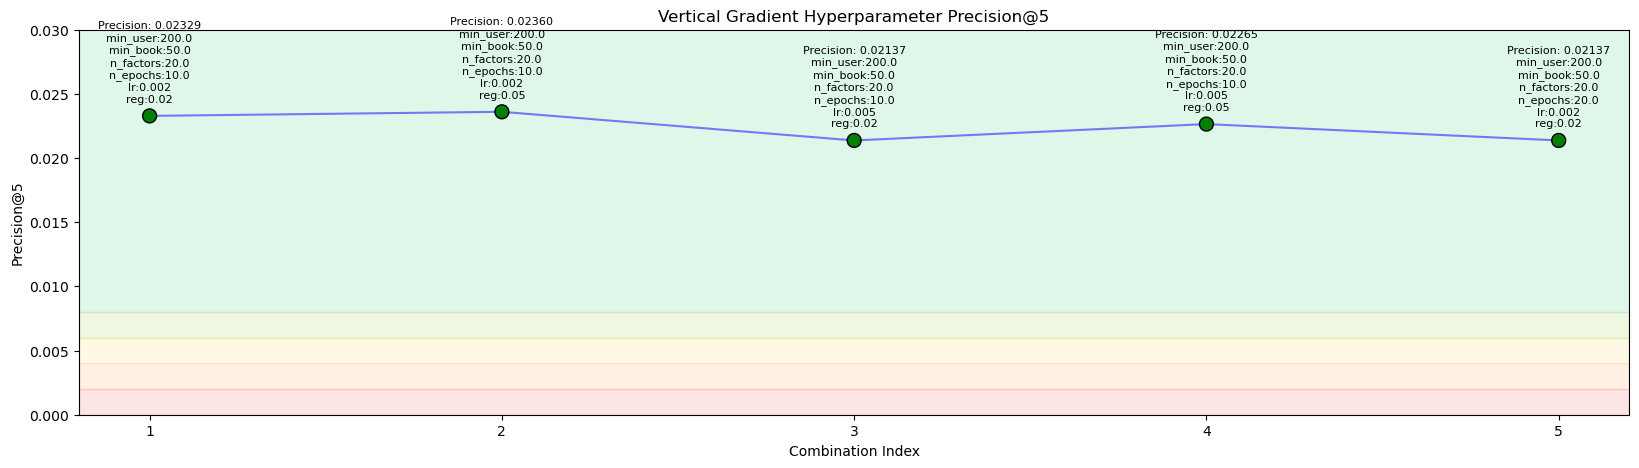

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

# Add combination_id as sequential numbers starting from 1
results_df = results_df.reset_index(drop=True)
results_df["combination_id"] = results_df.index + 1

zones = [
    (0.000, 0.002, "#ff4d4d"),   # Very Poor
    (0.002, 0.004, "#ff944d"),   # Poor
    (0.004, 0.006, "#ffd24d"),   # Acceptable
    (0.006, 0.008, "#9acd32"),   # Good
    (0.008, 0.5, "#2ecc71")    # Excellent
]
        
# Set figure and axes
fig, ax = plt.subplots(figsize=(20,5))

# Y-axis limits slightly bigger than max precision, The 1.2 is just padding (extra space at top of graph).
y_min, y_max = 0, max(results_df["precision@5"])*1.2

y_ticks = np.arange(y_min, y_max + 0.005, 0.005) # [0.000, 0.005, 0.010, 0.015, ... 0.095]

# # Create vertical gradient: red > yellow > green, This creates numbers from 0 → 1 vertically as 0, 0.01,..., 1
# gradient = np.linspace(0, 1, 256).reshape(-1, 1)  # vertical gradient

# # Why repeat? Because imshow needs an image (2D matrix, We duplicate the column to make it wide
# gradient = np.repeat(gradient, 2, axis=1)

# # This draws a background image
# # extent	Where image appears in plot
# # origin='lower'	start gradient from bottom
# # cmap='RdYlGn'	Red → Yellow → Green colors
# # alpha=0.2	make transparent
# ax.imshow(gradient, extent=[0, len(results_df)+1, y_min, y_max],
#           origin='lower', aspect='auto',
#           cmap='RdYlGn', alpha=0.2)

# # Normalize precision for coloring dots, This converts precision values → colors, 
# colors = results_df["precision@5"].apply(get_color)

for y_start, y_end, color in zones:
    ax.axhspan(y_start, y_end, color=color, alpha=0.15, zorder=0)
    
# Scatter plot with dots colored by precision, size = 100 > big dots
ax.scatter(results_df["combination_id"], results_df["precision@5"],
           color=colors, edgecolors='black', s=100, zorder=5)

# Connect points with line
ax.plot(results_df["combination_id"], results_df["precision@5"],
        color='blue', linestyle='-', alpha=0.5, zorder=4)

# Annotate points, prints hyperparameters near each dot
for idx, row in results_df.iterrows():
    ax.annotate(
        f"Precision: {row['precision@5']:.5f}\n"
        f"min_user:{row['min_user']}\nmin_book:{row['min_book']}\n"
        f"n_factors:{row['n_factors']}\n"
        f"n_epochs:{row['n_epochs']}\n"
        f"lr:{row['lr']}\n"
        f"reg:{row['reg']}",
        (row["combination_id"], row["precision@5"]),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=8
    )

# Labels and title
ax.set_xlabel("Combination Index")
ax.set_ylabel("Precision@5")
ax.set_title("Vertical Gradient Hyperparameter Precision@5")
ax.set_xticks(results_df["combination_id"])
ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)

plt.show()

## **Exporting SVD**

In [26]:
import joblib
import os
import pandas as pd

# Create dir to save pkls
directory = "svd_pkls"
if not os.path.exists(directory):
    os.mkdir(directory)

# export model
joblib.dump(svd_model, f"{directory}/svd_model.pkl")

# export csv
train_ratings.to_csv(f"{directory}/train_ratings_svd.csv", index=False)
test_ratings.to_csv(f"{directory}/test_ratings_svd.csv", index=False)

# export book df
books.to_csv(f"{directory}/books.pkl", index=False)